# Tutorial 1 · Your first neuron

**What you'll learn.** How to instantiate a single spiking neuron from the
BrainPy-style library, inject an input current, run it forward in time, and
inspect its membrane potential and spike train.

**Who it's for.** Everyone — this is the entry point. No prior knowledge of the
API is assumed. (Audience: simulation and training.)

We use the leaky integrate-and-fire neuron with a refractory period,
`brainpy.state.LIFRef`. A neuron is a state-based `Module`: it owns its dynamical
variables (here the membrane potential `V`) as explicit `State` objects, and you
advance it one time step per call. To run it over many steps we never write a
bare Python `for` loop — we hand the per-step function to
`brainstate.transform.for_loop`, which compiles the whole rollout into a single
XLA program and stacks the outputs for us.

In [1]:
import brainpy
import brainstate
import braintools
import brainunit as u
import matplotlib.pyplot as plt

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


## Create the neuron

All quantities carry physical units (millivolts, milliseconds, …) via
`brainunit`. The constructor takes the population size first — here a single
neuron — followed by the membrane parameters.

In [2]:
with brainstate.environ.context(dt=0.1 * u.ms):
    neuron = brainpy.state.LIFRef(
        1,                     # one neuron
        R=1. * u.ohm,          # membrane resistance
        tau=20. * u.ms,        # membrane time constant
        V_rest=-60. * u.mV,    # resting potential
        V_th=-50. * u.mV,      # spike threshold
        V_reset=-60. * u.mV,   # reset after a spike
        tau_ref=5. * u.ms,     # refractory period
    )
    # Allocate the neuron's state variables (V, last_spike_time).
    brainstate.nn.init_all_states(neuron)

print(neuron)

LIFRef(
  in_size=(1,),
  out_size=(1,),
  spk_reset=soft,
  spk_fun=ReluGrad(alpha=0.3, width=1.0),
  R=Quantity(1., "ohm"),
  tau=Quantity(20., "ms"),
  tau_ref=Quantity(5., "ms"),
  V_th=Quantity(-50., "mV"),
  V_rest=Quantity(-60., "mV"),
  V_reset=Quantity(-60., "mV"),
  V_initializer=Constant(value=0. mV),
  V=HiddenState(
    value=Quantity(~float32[1], "mV")
  ),
  last_spike_time=ShortTermState(
    value=Quantity(~float32[1], "ms")
  )
)


## Drive it with a constant current

We define a single-step function that (1) opens an `environ.context` so the
model knows the current time `t`, (2) advances the neuron by one step with an
injected current, and (3) returns what we want to record. Then `for_loop`
repeats it across an array of time points.

`get_spike()` returns the spike output of the neuron for the current step.

In [3]:
with brainstate.environ.context(dt=0.1 * u.ms):
    times = u.math.arange(0. * u.ms, 200. * u.ms, brainstate.environ.get_dt())

    def step(t):
        with brainstate.environ.context(t=t):
            neuron(25. * u.mA)                 # inject a supra-threshold current
            return neuron.V.value, neuron.get_spike()

    vs, spikes = brainstate.transform.for_loop(step, times)

print('membrane trace shape:', vs.shape)
print('total spikes:', float(u.math.sum(spikes)))

membrane trace shape: (2000, 1)
total spikes: 17.0


## Plot the membrane potential and spikes

`vs` is a `brainunit` quantity; convert it to millivolts for plotting. The spike
times are simply the time points where the spike output is non-zero.

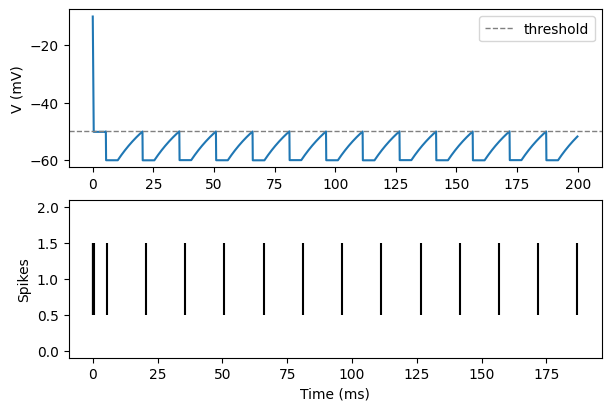

In [4]:
t_ms = times.to_decimal(u.ms)
v_mV = vs.to_decimal(u.mV)[:, 0]

fig, gs = braintools.visualize.get_figure(2, 1, 2.0, 6.0)

ax = fig.add_subplot(gs[0, 0])
ax.plot(t_ms, v_mV)
ax.axhline(-50., ls='--', color='gray', lw=1, label='threshold')
ax.set_ylabel('V (mV)')
ax.legend(loc='upper right')

ax = fig.add_subplot(gs[1, 0])
spk_idx, _ = u.math.where(spikes)
ax.eventplot(t_ms[spk_idx], colors='k')
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Spikes')
plt.show()

## Sub-threshold vs. supra-threshold input

A weaker current never reaches threshold, so the neuron charges toward a steady
state and never fires. Re-initialize the state and drive it more gently to see
the difference.

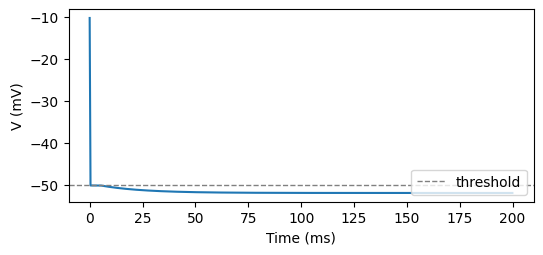

In [5]:
with brainstate.environ.context(dt=0.1 * u.ms):
    brainstate.nn.init_all_states(neuron)   # reset V back to rest

    def step_weak(t):
        with brainstate.environ.context(t=t):
            neuron(8. * u.mA)                 # sub-threshold drive
            return neuron.V.value

    vs_weak = brainstate.transform.for_loop(step_weak, times)

plt.figure(figsize=(6, 2.5))
plt.plot(t_ms, vs_weak.to_decimal(u.mV)[:, 0])
plt.axhline(-50., ls='--', color='gray', lw=1, label='threshold')
plt.xlabel('Time (ms)')
plt.ylabel('V (mV)')
plt.legend(loc='lower right')
plt.show()

## See also

- :doc:`02-synapse-and-projection` — connect two populations of these neurons.
- :doc:`/concepts/state-paradigm` — why models hold explicit `State` and why we
  drive them with `transform` loops instead of Python loops.
- :doc:`/concepts/physical-units` — the `brainunit` quantities used throughout.
- :doc:`/concepts/model-anatomy` — the `Dynamics → Neuron` hierarchy and the
  current-input contract.
- :doc:`../howto/sim-choose-neuron` — pick a different neuron model.